# Uber Drive Data Analysis using Python

##### Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np
import warnings
warnings.filterwarnings('ignore')

#### Load Dataset

In [2]:
df = pd.read_csv('uberdrive (1).csv')
df.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,01-01-2016 21:11,01-01-2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 01:25,01-02-2016 01:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20:25,01-02-2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17:31,01-05-2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14:42,01-06-2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


In [7]:
df.head(5)

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,DATE,TIME,DAY-NIGHT,MONTH,MINUTES,DAY,ROUNDTRIP
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,Evening,Jan,6.0,Friday,Yes
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,UNKNOWN,2016-01-02,1,Early Morning,Jan,12.0,Saturday,Yes
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,Evening,Jan,13.0,Saturday,Yes
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,Afternoon,Jan,14.0,Tuesday,Yes
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,Afternoon,Jan,67.0,Wednesday,No


#### Understanding the Dataset

In [3]:
df.shape,df.size,df.dtypes

((1156, 7),
 8092,
 START_DATE*     object
 END_DATE*       object
 CATEGORY*       object
 START*          object
 STOP*           object
 MILES*         float64
 PURPOSE*        object
 dtype: object)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1155 entries, 0 to 1154
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   START_DATE*  1155 non-null   datetime64[ns]
 1   END_DATE*    1155 non-null   datetime64[ns]
 2   CATEGORY*    1155 non-null   object        
 3   START*       1155 non-null   object        
 4   STOP*        1155 non-null   object        
 5   MILES*       1155 non-null   float64       
 6   PURPOSE*     1155 non-null   object        
 7   DATE         1155 non-null   object        
 8   TIME         1155 non-null   int32         
 9   DAY-NIGHT    1155 non-null   category      
 10  MONTH        1155 non-null   object        
 11  MINUTES      1155 non-null   float64       
 12  DAY          1155 non-null   object        
 13  ROUNDTRIP    1155 non-null   object        
 14  next_ride    1154 non-null   datetime64[ns]
 15  time_diff    1154 non-null   float64       
dtypes: cat

In [14]:
df.describe(include='all')

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,DATE,TIME,DAY-NIGHT,MONTH,MINUTES,DAY,ROUNDTRIP,next_ride,time_diff
count,1155,1155,1155,1155,1155,1155.000000,1155,1155,1155.000000,1155,1155,1155.000000,1155,1155,1154,1154.000000
unique,NaN,NaN,2,177,188,NaN,11,294,NaN,4,12,NaN,7,2,NaN,NaN
top,NaN,NaN,Business,Cary,Cary,NaN,UNKNOWN,2016-12-29,NaN,Afternoon,Dec,NaN,Friday,No,NaN,NaN
freq,NaN,NaN,1078,201,203,NaN,502,13,NaN,464,146,NaN,206,867,NaN,NaN
mean,2016-07-16 23:44:33.402597376,2016-07-17 00:07:47.999999744,NaN,NaN,NaN,10.566840,NaN,NaN,14.696104,NaN,NaN,23.243290,NaN,NaN,2016-07-17 03:50:30.779896064,455.508666
min,2016-01-01 21:11:00,2016-01-01 21:17:00,NaN,NaN,NaN,0.500000,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,2016-01-02 01:25:00,0.000000
25%,2016-04-01 02:10:00,2016-04-01 02:35:00,NaN,NaN,NaN,2.900000,NaN,NaN,12.000000,NaN,NaN,10.000000,NaN,NaN,2016-04-01 13:56:15,54.000000
50%,2016-07-21 17:17:00,2016-07-21 17:23:00,NaN,NaN,NaN,6.000000,NaN,NaN,15.000000,NaN,NaN,16.000000,NaN,NaN,2016-07-21 17:29:30,121.500000
75%,2016-10-27 21:06:30,2016-10-27 21:21:00,NaN,NaN,NaN,10.400000,NaN,NaN,18.000000,NaN,NaN,27.500000,NaN,NaN,2016-10-27 21:16:15,563.750000
max,2016-12-31 22:08:00,2016-12-31 23:51:00,NaN,NaN,NaN,310.300000,NaN,NaN,23.000000,NaN,NaN,336.000000,NaN,NaN,2016-12-31 22:08:00,6880.000000


### Data Cleaning

In [3]:
df.drop(df.index[-1],inplace=True)

In [4]:
df['PURPOSE*'].fillna('UNKNOWN', inplace=True)

In [ ]:
df.drop_duplicates(inplace=True)


In [5]:
df['START_DATE*'] = pd.to_datetime(df['START_DATE*'], format='mixed', errors='coerce')
df['END_DATE*'] = pd.to_datetime(df['END_DATE*'], format='mixed', errors='coerce')

#### Feature Engineering

In [6]:
from datetime import datetime
df['DATE'] = pd.DatetimeIndex(df['START_DATE*']).date
df['TIME'] = pd.DatetimeIndex(df['START_DATE*']).hour
df['DAY-NIGHT'] = pd.cut(x = df['TIME'], bins = (-1,6,12,17,23), labels=['Early Morning', 'Morning', 'Afternoon', 'Evening'])
df['MONTH'] = pd.DatetimeIndex(df['START_DATE*']).month
dict = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
df['MONTH'] = df['MONTH'].map(dict)
df['MINUTES'] = (df['END_DATE*'] - df['START_DATE*']).dt.total_seconds() / 60
df['DAY'] = df['START_DATE*'].dt.day_name()
def round_trip(x):
  if x['START*'] == x['STOP*']:
     return 'Yes'
  else:
     return 'No'
df['ROUNDTRIP'] = df.apply(round_trip, axis=1)


### Exploratory Data Analysis (EDA)

<Figure size 1500x500 with 0 Axes>

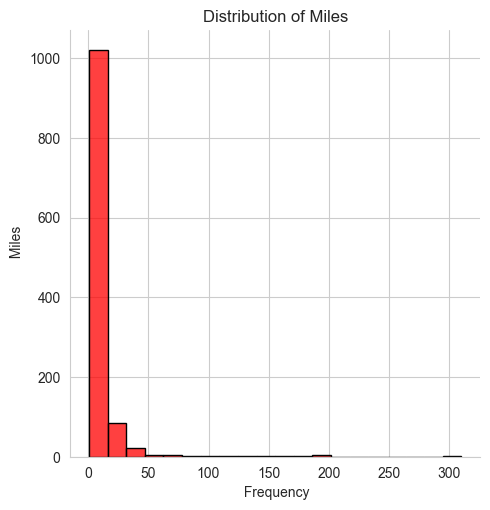

In [45]:
from matplotlib import colors
plt.figure(figsize=(15,5))
sns.displot(df['MILES*'], bins = 20, color= 'red',edgecolor='black')
plt.title('Distribution of Miles')
plt.xlabel(' Frequency')
plt.ylabel(' Miles')
plt.show()

In [44]:
obj = (df.dtypes == 'object')
object_cols = list(obj[obj].index)
unique_values = {}
for col in object_cols:
    unique_values[col] = df[col].unique().size
unique_values

{'CATEGORY*': 2,
 'START*': 176,
 'STOP*': 188,
 'PURPOSE*': 11,
 'DATE': 294,
 'MONTH': 12,
 'DAY': 7,
 'ROUNDTRIP': 2}

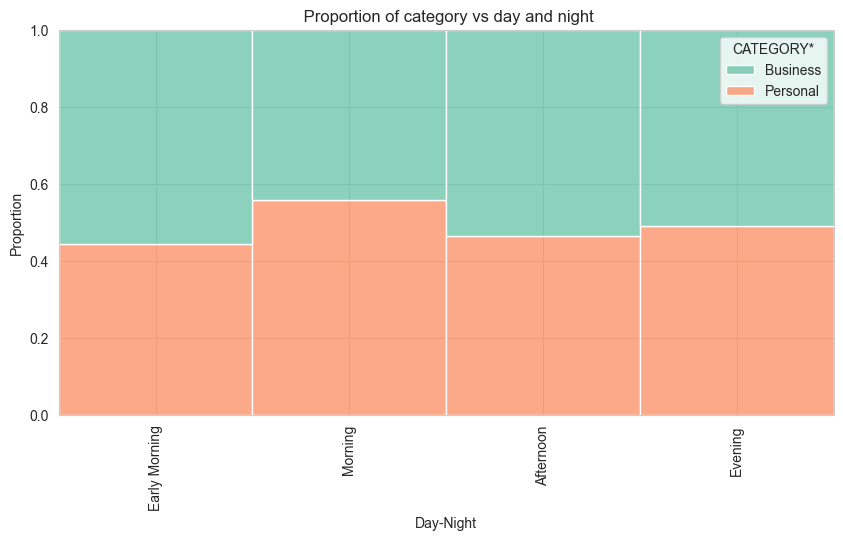

In [43]:
plt.figure(figsize=(10, 5))
sns.histplot(data = df, x = 'DAY-NIGHT', hue = 'CATEGORY*',stat='probability',common_norm= False, multiple = 'fill', palette = 'Set2')
plt.xticks(rotation = 90)
plt.title(' Proportion of category vs day and night')
plt.xlabel('Day-Night')
plt.ylabel('Proportion')
plt.show()

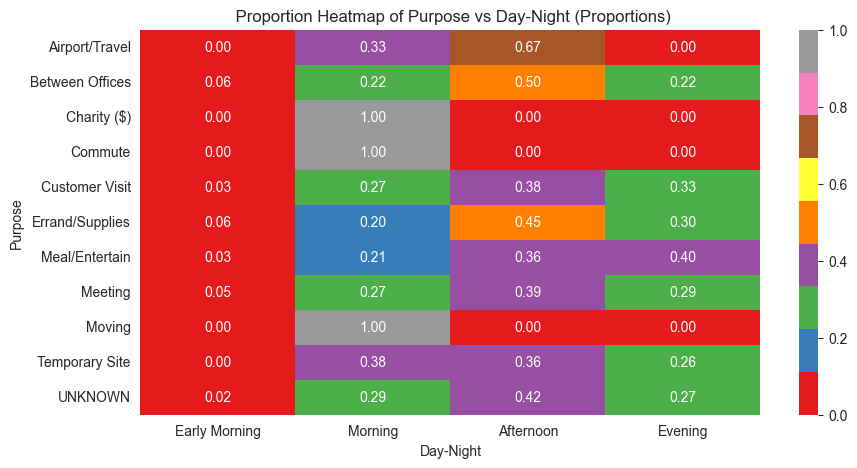

In [42]:
plt.figure(figsize=(10, 5))
heatmap_data = df.groupby(['PURPOSE*', 'DAY-NIGHT']).size().unstack()
heatmap_data = heatmap_data.div(heatmap_data.sum(axis = 1), axis=0)
sns.heatmap(heatmap_data, cmap='Set1', annot=True, fmt='.2f')
plt.title(' Proportion Heatmap of Purpose vs Day-Night (Proportions)')
plt.xlabel('Day-Night')
plt.ylabel('Purpose')
plt.show()

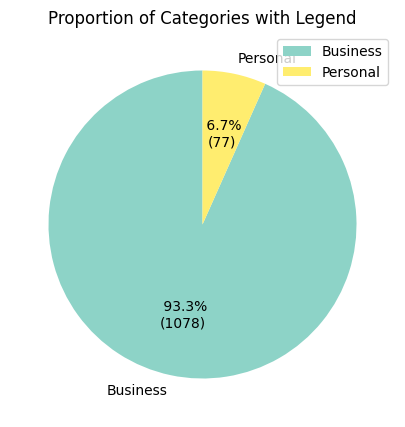

In [12]:
plt.figure(figsize=(10, 5))
def autopct_with_counts(pct, values):
    total = sum(values)
    absolute = int(pct/100.*total)
    return f'{pct: .1f}%\n({absolute})'

df['CATEGORY*'].value_counts().plot.pie(
    autopct=lambda pct: autopct_with_counts(pct, df['CATEGORY*'].value_counts()), startangle=90, cmap='Set3')
plt.title('Proportion of Categories with Legend')
plt.ylabel('')
plt.legend(labels=df['CATEGORY*'].value_counts().index, loc='upper right')
plt.show()

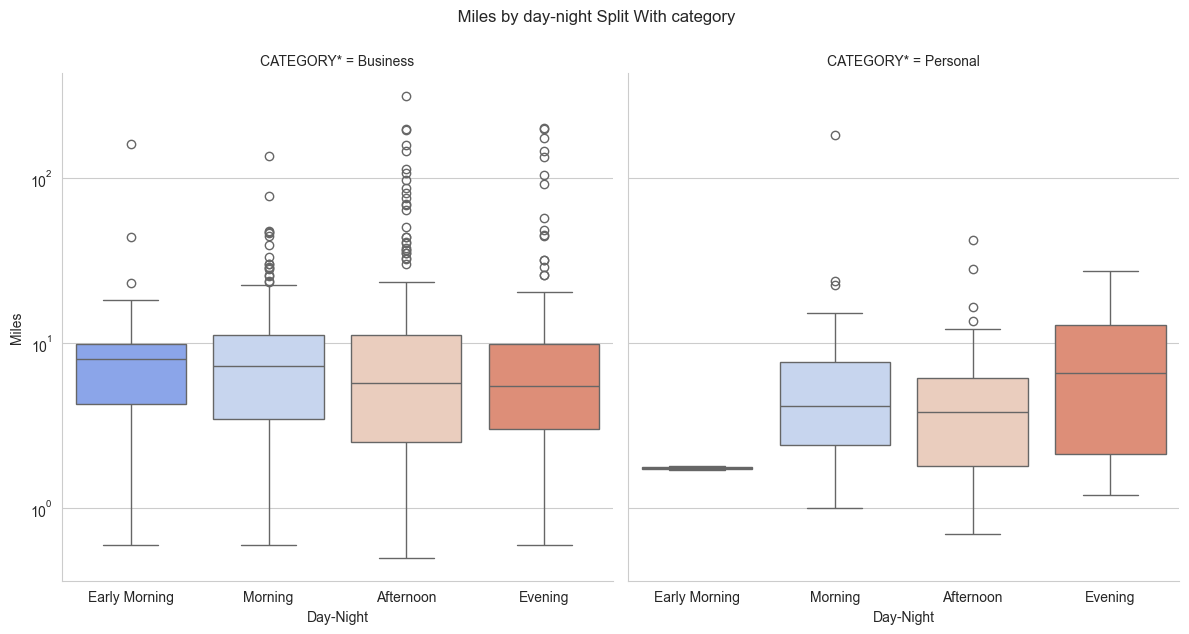

In [41]:
g = sns.FacetGrid(df, col = 'CATEGORY*', height=6, aspect=1)
g.map(sns.boxplot, 'DAY-NIGHT' , 'MILES*',palette = 'coolwarm')
plt.yscale('log')
g.set_axis_labels('Day-Night','Miles')
g.fig.suptitle(' Miles by day-night Split With category',y=1.05)
plt.show()

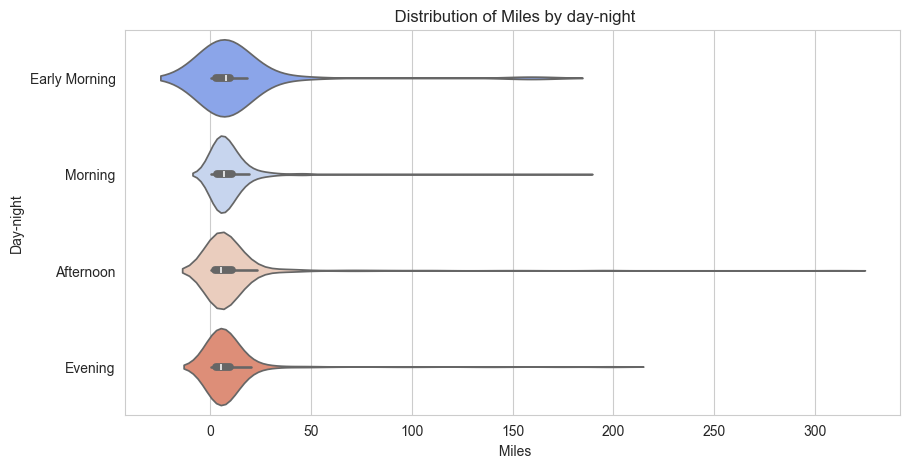

In [40]:
sns.set_style('whitegrid')
plt.figure(figsize=(10,5))
sns.violinplot(data = df , y = 'DAY-NIGHT' ,x = 'MILES*', scale = 'width', palette = 'coolwarm')
plt.title(' Distribution of Miles by day-night')
plt.xlabel(' Miles')
plt.ylabel('Day-night')
plt.show()

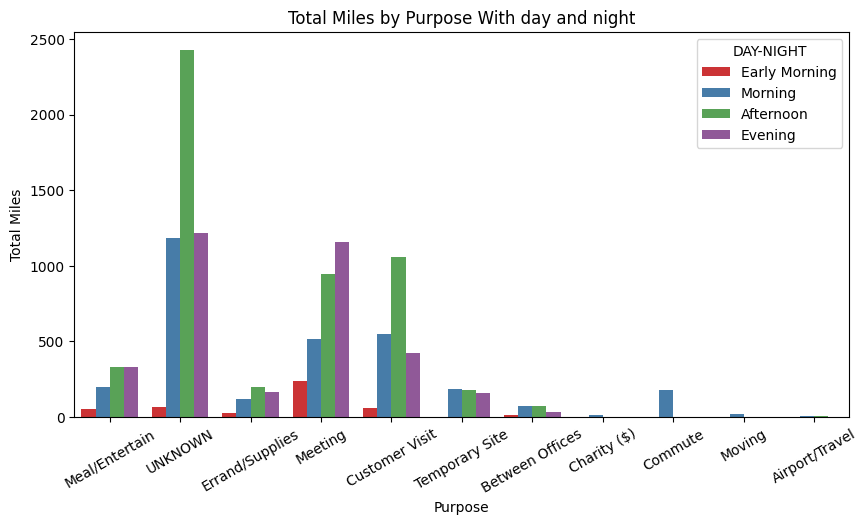

In [39]:
plt.figure(figsize=(10,5))
sns.barplot(data = df,x='PURPOSE*', y='MILES*',hue = 'DAY-NIGHT', estimator=sum,ci=None, palette='Set1')
plt.xticks(rotation=30)
plt.title('Total Miles by Purpose With day and night')
plt.xlabel('Purpose')
plt.ylabel('Total Miles')
plt.show()

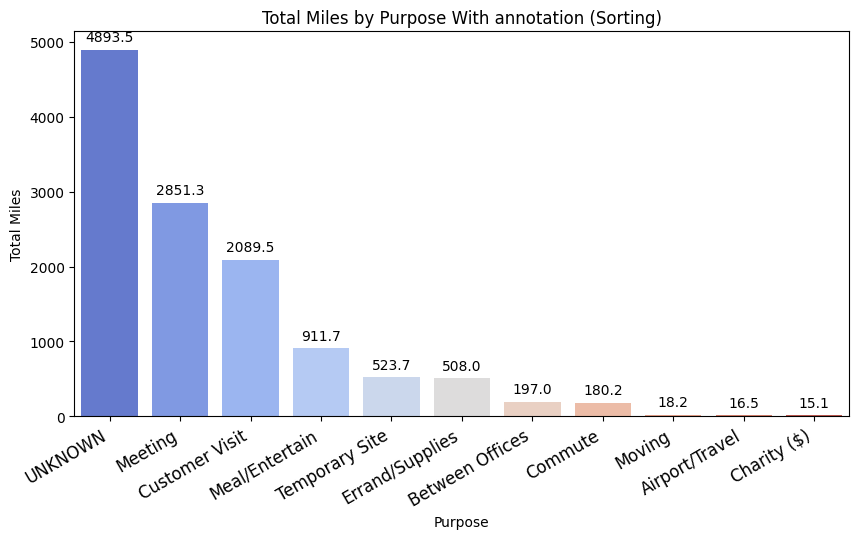

In [38]:
plt.figure(figsize=(10,5))
order = df.groupby('PURPOSE*')['MILES*'].sum().sort_values(ascending = False).index
ax = sns.barplot(data = df,x='PURPOSE*', y='MILES*', estimator=sum,errorbar=None, palette='coolwarm', order=order)
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), (p.get_x() + p.get_width() /2., p.get_height()), ha = 'center', va = 'center',xytext = (0, 9), textcoords = 'offset points')

plt.xticks(rotation=30, ha= 'right', fontsize = 12)
plt.title('Total Miles by Purpose With annotation (Sorting)')
plt.xlabel('Purpose')
plt.ylabel('Total Miles')
plt.show()

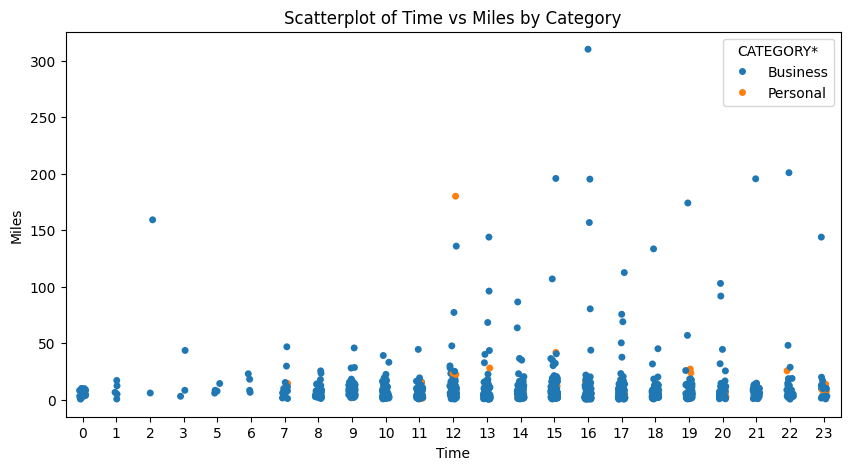

In [37]:
plt.figure(figsize=(10,5))
sns.stripplot(data = df , x = 'TIME', y = 'MILES*', hue= 'CATEGORY*', jitter = True)
plt.title('Scatterplot of Time vs Miles by Category')
plt.xlabel('Time')
plt.ylabel('Miles')
plt.show()

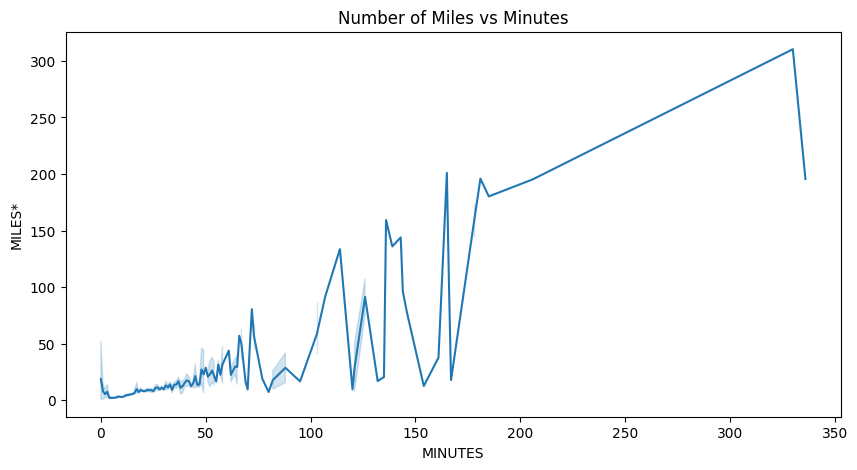

In [33]:
plt.figure(figsize=(10,5))
sns.lineplot(data = df,x = df['MINUTES'],y = df['MILES*'])
plt.title('Number of Miles vs Minutes')
plt.show()

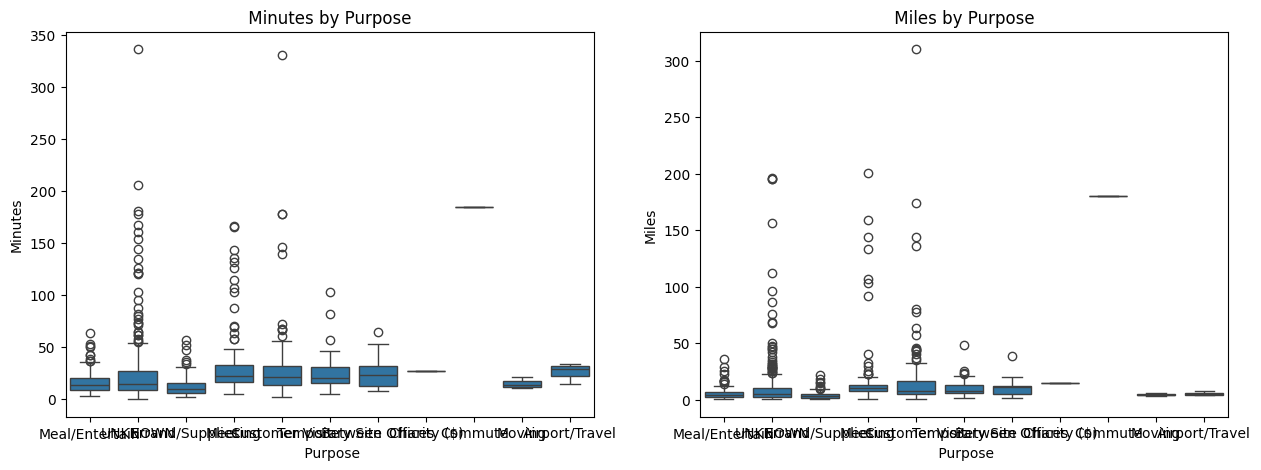

In [34]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data = df , x = 'PURPOSE*' ,y = 'MINUTES')
plt.title(' Minutes by Purpose ')
plt.xlabel(' Purpose')
plt.ylabel('Minutes')
plt.subplot(1,2,2)
sns.boxplot(data = df , x = 'PURPOSE*' ,y = 'MILES*')
plt.title(' Miles by Purpose ')
plt.xlabel(' Purpose')
plt.ylabel('Miles')
plt.show()

In [46]:
pd.set_option('display.max_rows', 100)
df.groupby(['MONTH','PURPOSE*'])['ROUNDTRIP'].count()

MONTH  PURPOSE*       
Apr    Between Offices      3
       Customer Visit       9
       Errand/Supplies      7
       Meal/Entertain      11
       Meeting             17
       Temporary Site       3
       UNKNOWN              4
Aug    Airport/Travel       1
       Customer Visit       3
       Meal/Entertain       1
       Meeting              2
       Temporary Site       5
       UNKNOWN            121
Dec    Airport/Travel       2
       Between Offices      1
       Customer Visit      24
       Errand/Supplies     41
       Meal/Entertain      29
       Meeting             28
       Temporary Site       9
       UNKNOWN             12
Feb    Between Offices      1
       Customer Visit       9
       Errand/Supplies     14
       Meal/Entertain      17
       Meeting             25
       Temporary Site      16
       UNKNOWN             33
Jan    Customer Visit      11
       Errand/Supplies     13
       Meal/Entertain      14
       Meeting             18
       Temporary 

In [ ]:
pd.DataFrame({
    'Min': df.groupby('PURPOSE*')['MILES*'].min(),
    'Mean': df.groupby('PURPOSE*')['MILES*'].mean(),
    'Max': df.groupby('PURPOSE*')['MILES*'].max()
})

,Min,Mean,Max
PURPOSE*,,,
Airport/Travel,4.1,5.500000,7.6
Between Offices,1.9,10.944444,39.2
Charity ($),15.1,15.100000,15.1
Commute,180.2,180.200000,180.2
Customer Visit,0.8,20.688119,310.3
Errand/Supplies,0.5,3.968750,22.3
Meal/Entertain,0.6,5.698125,36.5
Meeting,0.7,15.247594,201.0
Moving,3.3,4.550000,6.1


### Business Questions

#### Are there More Rides  on Weekdays or weekends?

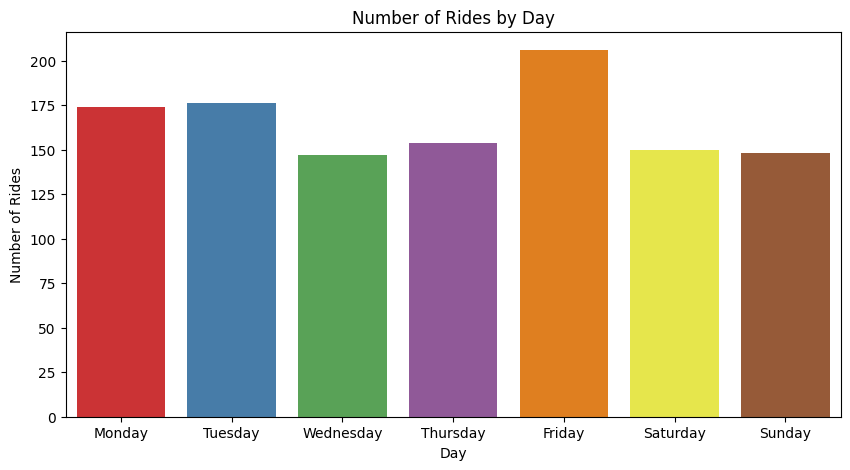

In [25]:
plt.figure(figsize=(10,5))
sns.countplot(data = df , x = 'DAY' ,order = ['Monday','Tuesday','Wednesday' ,'Thursday' ,'Friday' ,'Saturday','Sunday'], palette='Set1')
plt.title('Number of Rides by Day')
plt.xlabel('Day')
plt.ylabel('Number of Rides')
plt.show()

#### How Many Rides ware Roundtrips?

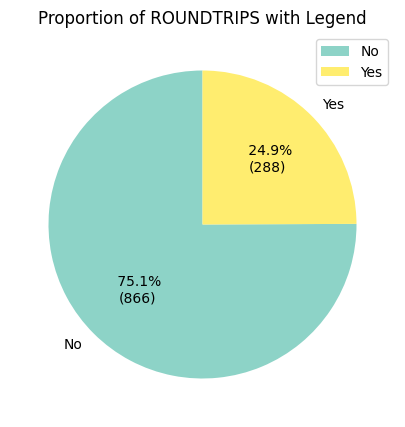

In [26]:
plt.figure(figsize=(10, 5))
def autopct_with_counts(pct, values):
    total = sum(values)
    absolute = int(pct/100.*total)
    return f'{pct: .1f}%\n({absolute})'

df['ROUNDTRIP'].value_counts().plot.pie(
    autopct=lambda pct: autopct_with_counts(pct, df['CATEGORY*'].value_counts()), startangle=90, cmap='Set3')
plt.title('Proportion of ROUNDTRIPS with Legend')
plt.ylabel('')
plt.legend(labels=df['ROUNDTRIP'].value_counts().index, loc='upper right')
plt.show()


#### What is the total Niles Travelled In each Category?

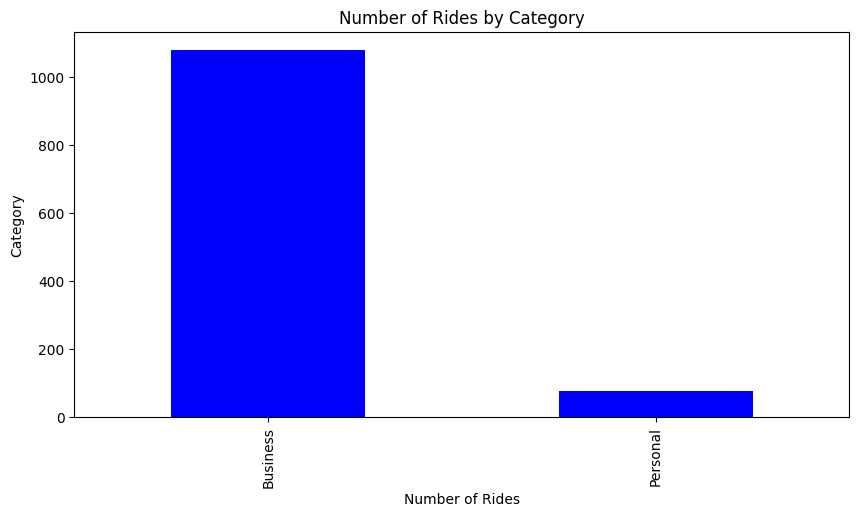

In [27]:
total_rides = df.groupby('CATEGORY*')['MILES*'].count()
plt.figure(figsize=(10, 5))
total_rides.plot(kind='bar', color='blue')
plt.title('Number of Rides by Category')
plt.xlabel('Number of Rides')
plt.ylabel('Category')
plt.show()

#### How does the Rides Count Change Across Different months?

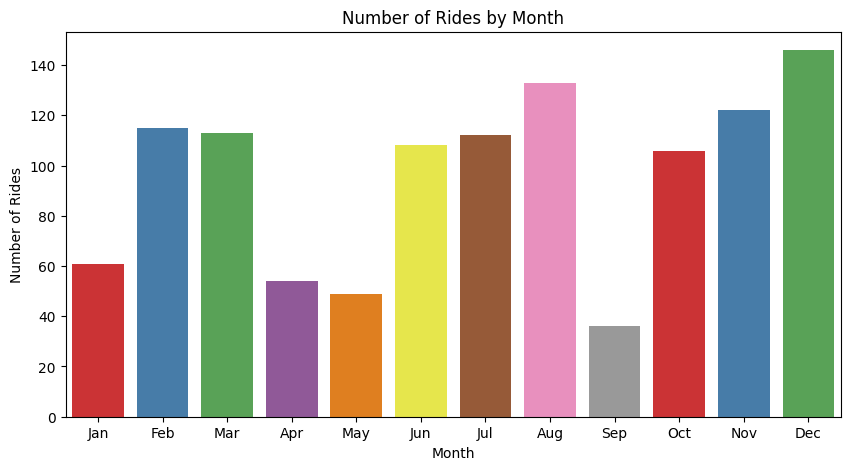

In [28]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x = 'MONTH',palette='Set1')
plt.title('Number of Rides by Month')
plt.xlabel('Month')
plt.ylabel('Number of Rides')
plt.show()

#### Which Starting Location is the Highest Number of Rides?

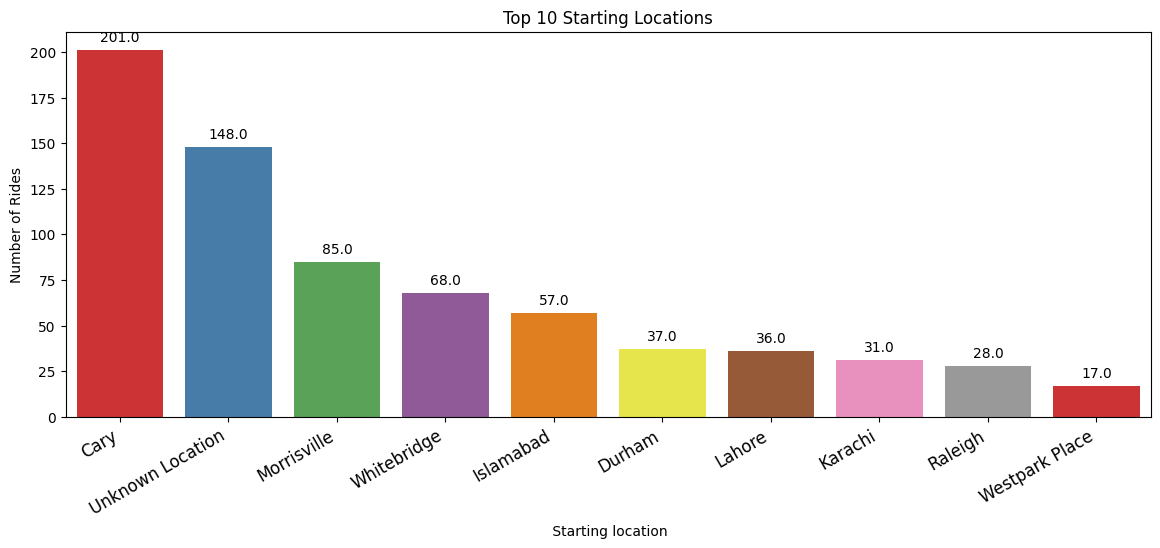

In [29]:
df['START*'] = df['START*'].replace('Kar?chi','Karachi')
plt.figure(figsize=(14, 5))
top_start_locations = df['START*'].value_counts().head(10)
ax = sns.countplot(x ='START*', order=top_start_locations.index, data=df, palette='Set1')
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), (p.get_x() + p.get_width() /2., p.get_height()), ha = 'center', va = 'center',xytext = (0, 9), textcoords = 'offset points')

plt.xticks(rotation=30, ha= 'right', fontsize = 12)
plt.title('Top 10 Starting Locations')
plt.xlabel(' Starting location')
plt.ylabel('Number of Rides')
plt.show()

#### What are the Busiest Time of Day for time?

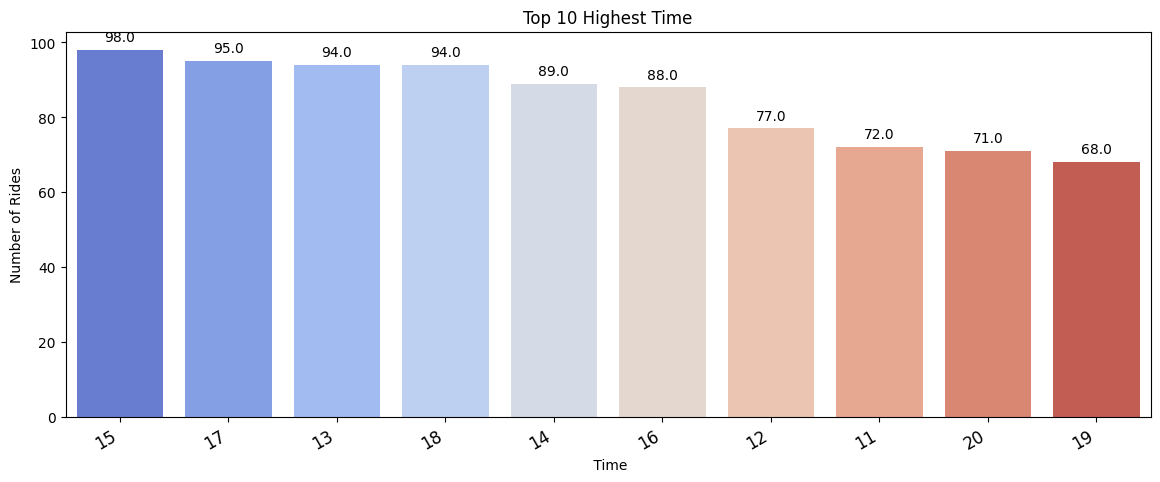

In [14]:
plt.figure(figsize=(14, 5))
top_start_locations = df['TIME'].value_counts().head(10)
ax = sns.countplot(x ='TIME', order=top_start_locations.index, data=df, palette='coolwarm')
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f'), (p.get_x() + p.get_width() /2., p.get_height()), ha = 'center', va = 'center',xytext = (0, 9), textcoords = 'offset points')

plt.xticks(rotation=30, ha= 'right', fontsize = 12)
plt.title('Top 10 Highest Time')
plt.xlabel(' Time')
plt.ylabel('Number of Rides')
plt.show()

#### What is the Top 5 Most Common Purpose?

In [23]:
df['PURPOSE*'].value_counts().head(5)


PURPOSE*
UNKNOWN            502
Meeting            187
Meal/Entertain     160
Errand/Supplies    128
Customer Visit     101
Name: count, dtype: int64

#### What are the Largest and Shortest Ride Duration for each Category?

In [22]:
pd.DataFrame({
    'Min': df.groupby('CATEGORY*')['MINUTES'].min(),
    'Max': df.groupby('CATEGORY*')['MINUTES'].max()
})

,Min,Max
CATEGORY*,,
Business,0.0,336.0
Personal,4.0,185.0


#### What is the Total number of Miles Travelled Each Month Under Which Month had most Miles Travelled?

In [21]:
df.groupby('MONTH')['MILES*'].sum()

MONTH
Apr    1113.0
Aug    1335.5
Dec     981.3
Feb     908.2
Jan     512.9
Jul    1224.6
Jun     842.8
Mar    1693.9
May     363.8
Nov     816.9
Oct    1810.0
Sep     601.8
Name: MILES*, dtype: float64

#### What is the Average number of Rides per Day For each Day in Week?

In [25]:
ride_day = df.groupby('DAY').size()
ave_day = ride_day / df['DAY'].nunique()
print(ave_day)

DAY
Friday       12.428571
Monday        8.857143
Saturday      7.428571
Sunday        6.857143
Thursday      8.714286
Tuesday       8.714286
Wednesday     7.142857
dtype: float64


#### Which Start location have Most Roundtrips Rides and How many?

In [20]:
df[df['ROUNDTRIP'] == 'Yes'].groupby('START*').size().sort_values(ascending = False).head(5)

START*
Unknown Location    86
Cary                53
Lahore              27
Islamabad           25
Kar?chi             20
dtype: int64

#### What is Average Distance For Ride That Happen During Different Miles of the Day?

In [18]:
df.groupby('DAY-NIGHT')['MILES*'].mean()

DAY-NIGHT
Early Morning    12.348649
Morning           9.730671
Afternoon        11.254741
Evening          10.204985
Name: MILES*, dtype: float64

#### How many Rides In Start and Stop In the same Location And How many Rides do these Rides cover on aaverage?

In [17]:
same_location = df[df['START*'] == df['STOP*']]
num_same_location = same_location.shape[0]
ave_same_location = same_location['MILES*'].mean()
print(num_same_location,ave_same_location)

288 7.742361111111112


#### What Purpose has the Highest Average Ride And What is there Average Distance of the Purpose?

In [16]:
df.groupby('PURPOSE*')['MINUTES'].mean()

PURPOSE*
Airport/Travel      26.000000
Between Offices     25.500000
Charity ($)         27.000000
Commute            185.000000
Customer Visit      33.415842
Errand/Supplies     12.976562
Meal/Entertain      16.125000
Meeting             29.737968
Moving              15.000000
Temporary Site      25.860000
UNKNOWN             23.041833
Name: MINUTES, dtype: float64

#### What is the Common combination of start and Stop and How many Times Does the Combination Appears in the Dataet?

In [15]:
df.groupby(['START*', 'STOP*']).size().sort_values(ascending = False).head(3)

START*            STOP*           
Unknown Location  Unknown Location    86
Morrisville       Cary                75
Cary              Morrisville         67
dtype: int64

#### What is the Average Time Different Between the Start of the first Ride and Start of the next Ride For each Uniwue Day?

In [12]:
df = df.sort_values('START_DATE*')
df['next_ride'] = df['START_DATE*'].shift(-1)
df['time_diff'] = (df['next_ride'] - df['START_DATE*']).dt.total_seconds() / 60
ave_time_diff = df.groupby('DATE')['time_diff'].mean()
print(ave_time_diff)

DATE
2016-01-01     254.000000
2016-01-02    2643.000000
2016-01-05    1271.000000
2016-01-06     455.000000
2016-01-07    3998.000000
                 ...     
2016-12-27     255.333333
2016-12-28     139.285714
2016-12-29     154.307692
2016-12-30     178.400000
2016-12-31     315.250000
Name: time_diff, Length: 294, dtype: float64


735
